# Reinforcement Learning, Live: Which Post Should the Algorithm Show?

**Scenario:** You run the social media account for an airline (same brand story as our
supervised-learning and unsupervised-learning demos earlier in the session). Every time
someone opens the app, your algorithm has to pick **one type of post** to show them:

- Flight Deals
- Customer Service Replies
- Memes / Fun Content
- Flight Status Updates
- Apology / Complaint Responses

The algorithm doesn't know in advance which post type people actually engage with
(click/like/comment). It only finds out **after** it shows a post and observes whether
the person engaged or not. That feedback loop — try something, get a reward (or not),
adjust — is the heart of **Reinforcement Learning (RL)**.

This is a simplified version of RL called a **multi-armed bandit**. It's exactly the
kind of problem real recommendation engines (Instagram, TikTok, X/Twitter, YouTube)
solve billions of times a day: *given no labels and no fixed categories, which action
maximizes engagement over time?*

> Contrast with the earlier demos:
> - **Supervised learning** — we had labeled tweets (positive/negative) and trained a
>   model to predict labels for new tweets.
> - **Unsupervised learning** — we had unlabeled tweets and let the model group them
>   into themes on its own.
> - **Reinforcement learning (this notebook)** — there is no dataset at all to start.
>   The algorithm generates its own experience by acting, observing a reward, and
>   updating its strategy.

Run each cell top to bottom. The live chart will redraw as the algorithm learns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — The "hidden truth" the algorithm must discover

In real life, nobody hands the algorithm these numbers — it has to learn them by
trial and error. We define them here only so we (the instructor) can peek behind
the curtain and verify the algorithm is learning correctly.

In [2]:
# Post types and their TRUE (hidden) engagement probabilities.
# The algorithm does NOT get to see this dictionary — it can only observe outcomes.
post_types = [
    "Flight Deals",
    "Customer Service Reply",
    "Meme / Fun Content",
    "Flight Status Update",
    "Apology / Complaint Response",
]

true_engagement_rate = {
    "Flight Deals": 0.42,
    "Customer Service Reply": 0.18,
    "Meme / Fun Content": 0.30,
    "Flight Status Update": 0.22,
    "Apology / Complaint Response": 0.10,
}

def show_post_and_get_engagement(post_type):
    # Simulates showing a post to a user and observing engagement (1) or not (0).
    p = true_engagement_rate[post_type]
    return 1 if np.random.random() < p else 0

print("Environment ready. True rates are hidden from the algorithm during learning.")

Environment ready. True rates are hidden from the algorithm during learning.


## Step 2 — The algorithm (epsilon-greedy bandit)

The strategy is simple and easy to explain to a non-technical audience:

- **Explore** (with probability `epsilon`): pick a random post type, just to gather
  more information.
- **Exploit** (otherwise): pick whichever post type has looked best *so far*.

Over time, as the algorithm gathers more evidence, it exploits more and explores less,
converging on the truly best-performing post type.

In [3]:
class EpsilonGreedyBandit:
    def __init__(self, actions, epsilon=0.1):
        self.actions = actions
        self.epsilon = epsilon
        self.counts = {a: 0 for a in actions}
        self.estimated_rate = {a: 0.0 for a in actions}

    def choose_action(self):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.actions)          # explore
        return max(self.estimated_rate, key=self.estimated_rate.get)  # exploit best-so-far

    def update(self, action, reward):
        self.counts[action] += 1
        n = self.counts[action]
        old_estimate = self.estimated_rate[action]
        # incremental average: new_estimate = old + (reward - old) / n
        self.estimated_rate[action] = old_estimate + (reward - old_estimate) / n

print("Bandit algorithm defined.")

Bandit algorithm defined.


## Step 3 — Run it live

This cell runs the simulation round by round and **redraws the chart every few
rounds**, so in class you can visibly watch the bars move as the algorithm updates
its beliefs, and watch which post type it starts favoring.

Feel free to change `EPSILON` and `N_ROUNDS` and re-run to show the class how more
exploration (higher epsilon) changes the learning curve.

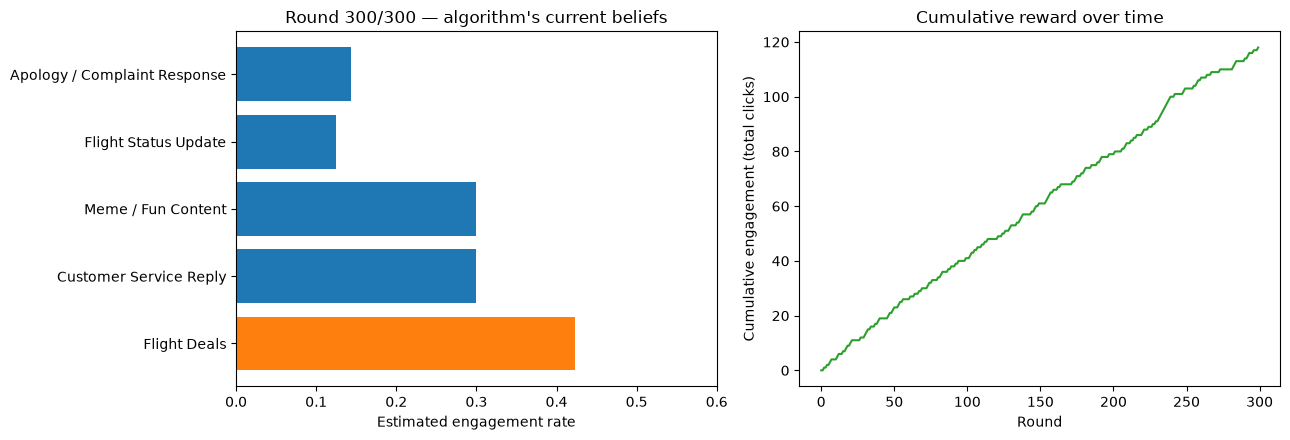

\nFinal learned estimates vs. hidden true rates:
  Flight Deals                      learned=0.422   true=0.420   times_shown=258
  Customer Service Reply            learned=0.300   true=0.180   times_shown=10
  Meme / Fun Content                learned=0.300   true=0.300   times_shown=10
  Flight Status Update              learned=0.125   true=0.220   times_shown=8
  Apology / Complaint Response      learned=0.143   true=0.100   times_shown=14


In [4]:
EPSILON = 0.15      # chance of random exploration (try 0.01 vs 0.5 to compare)
N_ROUNDS = 300       # total number of simulated app opens
REDRAW_EVERY = 10    # how often to update the live chart

bandit = EpsilonGreedyBandit(post_types, epsilon=EPSILON)

history_reward = []
history_choice = []
cumulative_reward = 0
cumulative_reward_history = []

for round_num in range(1, N_ROUNDS + 1):
    action = bandit.choose_action()
    reward = show_post_and_get_engagement(action)
    bandit.update(action, reward)

    cumulative_reward += reward
    history_reward.append(reward)
    history_choice.append(action)
    cumulative_reward_history.append(cumulative_reward)

    if round_num % REDRAW_EVERY == 0 or round_num == N_ROUNDS:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        # Left: algorithm's current estimated engagement rate per post type
        names = list(bandit.estimated_rate.keys())
        estimates = [bandit.estimated_rate[n] for n in names]
        colors = ["#1f77b4"] * len(names)
        best_so_far = max(bandit.estimated_rate, key=bandit.estimated_rate.get)
        colors[names.index(best_so_far)] = "#ff7f0e"

        axes[0].barh(names, estimates, color=colors)
        axes[0].set_xlim(0, 0.6)
        axes[0].set_xlabel("Estimated engagement rate")
        axes[0].set_title(f"Round {round_num}/{N_ROUNDS} — algorithm's current beliefs")

        # Right: cumulative reward over time (is it improving?)
        axes[1].plot(cumulative_reward_history, color="#2ca02c")
        axes[1].set_xlabel("Round")
        axes[1].set_ylabel("Cumulative engagement (total clicks)")
        axes[1].set_title("Cumulative reward over time")

        plt.tight_layout()
        plt.show()
        time.sleep(0.05)

print("\\nFinal learned estimates vs. hidden true rates:")
for a in post_types:
    print(f"  {a:32s}  learned={bandit.estimated_rate[a]:.3f}   true={true_engagement_rate[a]:.3f}   times_shown={bandit.counts[a]}")

## Step 4 — Did it shift from exploring to exploiting?

This chart shows, for each block of 20 rounds, how often each post type was chosen.
Early on choices should look scattered (exploring). Later, one or two post types
should dominate (exploiting what it has learned).

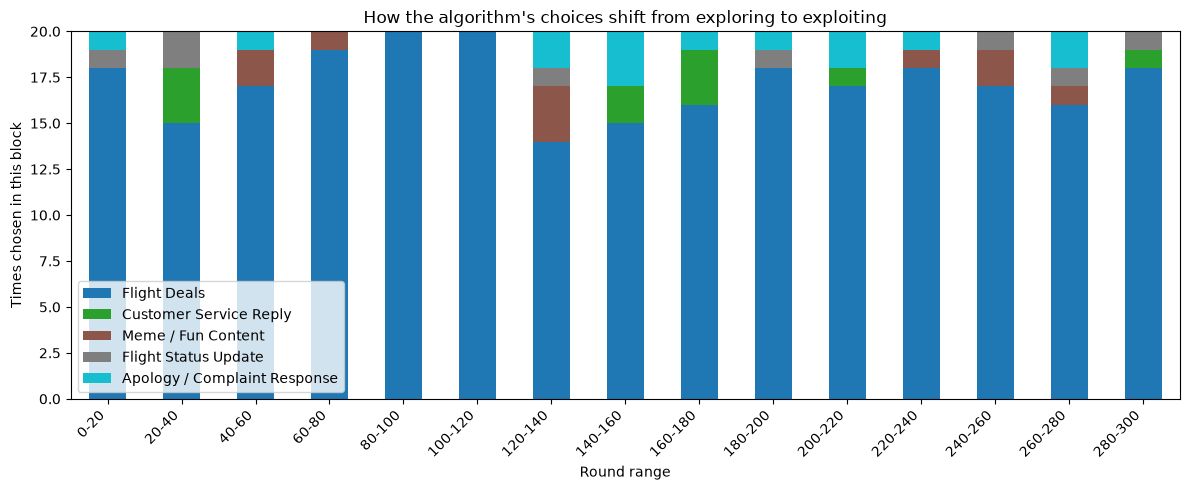

In [5]:
import pandas as pd

block_size = 20
n_blocks = len(history_choice) // block_size

rows = []
for b in range(n_blocks):
    block = history_choice[b * block_size:(b + 1) * block_size]
    counts = {a: block.count(a) for a in post_types}
    counts["block"] = f"{b*block_size}-{(b+1)*block_size}"
    rows.append(counts)

df = pd.DataFrame(rows).set_index("block")

ax = df.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
ax.set_ylabel("Times chosen in this block")
ax.set_xlabel("Round range")
ax.set_title("How the algorithm's choices shift from exploring to exploiting")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Talking points for the class

1. **No labels, no fixed dataset.** Unlike the supervised and unsupervised demos, this
   algorithm started with *zero* information. Everything it "knows" it earned by
   trying things and observing outcomes.
2. **Explore vs. exploit.** Early rounds look random-ish (exploring). Later rounds
   concentrate on the best-performing post type (exploiting). This tension is the
   central idea of RL.
3. **This is exactly how real feeds work.** Instagram, TikTok, and X don't have a
   labeled dataset saying "this post is good for this user." They run this same
   explore/exploit loop constantly, at massive scale, personalized per user.
4. **Try it live:** change `EPSILON` to `0.02` (almost no exploring) and re-run —
   ask the class to predict what will happen (it may get stuck on a mediocre choice
   early and never discover the best one). Then try `EPSILON = 0.5` (lots of
   exploring) and compare.
5. **One dataset, three mindsets.** Same brand/story throughout the session:
   - Supervised: learn from labeled tweets → predict sentiment.
   - Unsupervised: group unlabeled tweets → discover themes.
   - Reinforcement: no data at all → learn from trial, error, and reward.